<a href="https://colab.research.google.com/github/Mohammed287-lab/ANN/blob/main/project%20.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
df = pd.read_csv('creditcard.csv')

Dataset shape after cleaning 'Class': (284807, 31)
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.14

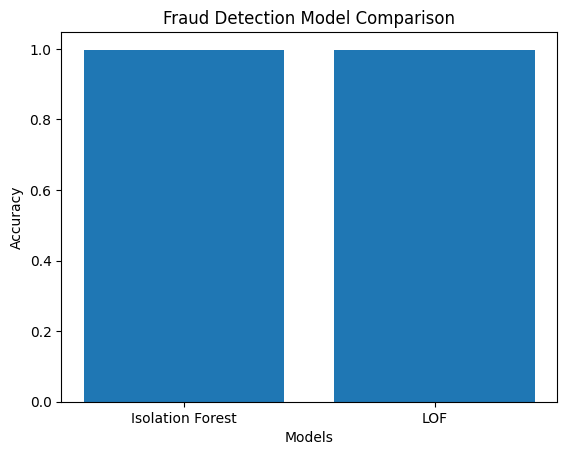

In [4]:
# ==========================================
# FRAUD DETECTION USING ANOMALY DETECTION
# Isolation Forest + Local Outlier Factor
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# Load dataset
df = pd.read_csv("creditcard.csv")

# Remove rows where the 'Class' column (target variable) is NaN
# This is crucial because sklearn metrics do not handle NaN in y_true.
original_shape = df.shape
df.dropna(subset=['Class'], inplace=True)
if df.shape[0] < original_shape[0]:
    print(f"Removed {original_shape[0] - df.shape[0]} rows due to NaN values in the 'Class' column.")

print("Dataset shape after cleaning 'Class':", df.shape)
print(df.head())

# Separate features and target
X = df.drop("Class", axis=1)
y = df["Class"]

# Ensure y is integer type for classification metrics
y = y.astype(int)

# ------------------------------------------
# Isolation Forest
# ------------------------------------------
model_iforest = IsolationForest(
    n_estimators=100,
    contamination=0.0017,   # fraud percentage
    random_state=42
)

model_iforest.fit(X)

pred_iforest = model_iforest.predict(X)

# Convert output:
# 1 -> normal
# -1 -> anomaly
pred_iforest = np.where(pred_iforest == -1, 1, 0)

print("\n===== Isolation Forest Results =====")
print("Accuracy:", accuracy_score(y, pred_iforest))
print(confusion_matrix(y, pred_iforest))
print(classification_report(y, pred_iforest))

# ------------------------------------------
# Local Outlier Factor
# ------------------------------------------
model_lof = LocalOutlierFactor(
    n_neighbors=20,
    contamination=0.0017
)

pred_lof = model_lof.fit_predict(X)

pred_lof = np.where(pred_lof == -1, 1, 0)

print("\n===== LOF Results =====")
print("Accuracy:", accuracy_score(y, pred_lof))
print(confusion_matrix(y, pred_lof))
print(classification_report(y, pred_lof))

# ------------------------------------------
# Compare models
# ------------------------------------------
iforest_acc = accuracy_score(y, pred_iforest)
lof_acc = accuracy_score(y, pred_lof)

models = ["Isolation Forest", "LOF"]
accuracies = [iforest_acc, lof_acc]

plt.bar(models, accuracies)
plt.title("Fraud Detection Model Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.show()